# Additional Lecture 1 — Data Augmentation with Generative AI
### *Machine Learning in the Generative AI Era* (Lecture 1 of 3)

**Course:** DA631E — Artificial Intelligence for Data Science · Malmö University
**Lecturer:** Ezequiel López-Rubio · **Date:** Tuesday, 22 September 2026

This notebook is the hands-on companion to the lecture slides. You will **augment a tiny
dataset in each of four modalities** — *text, tabular, image, audio* — and inspect the result.

> **Augmentation = transform existing labelled examples with *label-preserving* changes.**

---
### Before you start
1. **Enable the free GPU:** *Runtime → Change runtime type → T4 GPU* (CPU also works, just slower).
2. Run the cells **top to bottom**. Each modality is a short, self-contained section.
3. Everything is deliberately **tiny** — this is a demonstration, not a benchmark, and it must
   stay within the free Colab tier. We load **one model at a time** and free memory in between.
4. *Did augmentation help?* is an **evaluation** question — formalised in **Lecture 7**. Today we only *peek*.


## 0 · Common setup (run once)

In [1]:
# Core libraries used across the notebook. Extra per-modality installs appear in their sections.
!pip -q install "transformers>=4.44" accelerate sentencepiece scikit-learn

import gc, torch

def free_memory(*objs):
    """Delete large objects and clear the GPU cache between sections."""
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

DEVICE = 0 if torch.cuda.is_available() else -1
print("GPU available:", torch.cuda.is_available())

GPU available: True


## 1 · Text — LLM paraphrase augmentation

We use **`google/flan-t5-base`**, a small instruction-following text-to-text model, as a
controllable *paraphraser*. The prompt encodes the **label** so the sentiment is preserved.
We call the model directly via `generate` (robust across transformers versions — the
`text2text-generation` *pipeline task* was removed in newer releases).

In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# flan-t5 via the model API. One model serves BOTH the text and the
# tabular-text sections; we free it once, afterwards.
tok = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-base",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
).to("cuda" if torch.cuda.is_available() else "cpu")

def t2t(prompt, n=1, temperature=1.1, max_new_tokens=60):
    """Generate n text-to-text completions for a prompt; returns a list of strings."""
    inputs = tok(prompt, return_tensors="pt", truncation=True).to(model.device)
    out = model.generate(**inputs, do_sample=True, top_p=0.95,
                         temperature=temperature, max_new_tokens=max_new_tokens,
                         num_return_sequences=n)
    return [tok.decode(o, skip_special_tokens=True).strip() for o in out]

seed = [
    ("The battery lasts all day and charges fast.",   "positive"),
    ("Great screen and the price is fair.",           "positive"),
    ("Terrible support, I waited two hours on hold.",  "negative"),
    ("It broke after a week, total waste of money.",   "negative"),
]

def paraphrase(text, sentiment, n=2):
    prompt = (f"Paraphrase this {sentiment} product review. "
              f"Keep the same sentiment and meaning, but change the wording. "
              f"Review: {text}")
    return t2t(prompt, n=n, temperature=1.1, max_new_tokens=60)

print(paraphrase(*seed[0]))

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

['great battery', 'Five Stars']


In [3]:
import pandas as pd

rows = []
for t, y in seed:
    rows.append((t, y, "original"))
    for v in paraphrase(t, y, n=2):
        if v and v.lower() != t.lower():
            rows.append((v, y, "augmented"))

df_text = pd.DataFrame(rows, columns=["text", "label", "source"]).drop_duplicates("text")
print(df_text["source"].value_counts().to_dict())
df_text

{'augmented': 7, 'original': 4}


,text,label,source
0,The battery lasts all day and charges fast.,positive,original
1,"Great battery, very light and durable.",positive,augmented
2,This is our favorite light bulb from Japan. It...,positive,augmented
3,Great screen and the price is fair.,positive,original
4,Good product I have very few complaints but th...,positive,augmented
5,Five Stars,positive,augmented
6,"Terrible support, I waited two hours on hold.",negative,original
7,"There's not just one reason to recommence, it'...",negative,augmented
8,negative,negative,augmented
9,"It broke after a week, total waste of money.",negative,original


## 2 · Tabular — SMOTE for imbalance + LLM for free-text columns

Tabular augmentation has two complementary tools:
* **SMOTE** interpolates new *numeric* minority-class rows (the classic, zero-LLM augmenter).
* When a table contains **free-text columns**, we augment those with the LLM (reusing flan-t5).

In [4]:
!pip -q install imbalanced-learn
import numpy as np
from imblearn.over_sampling import SMOTE

# tiny imbalanced numeric table: 9 "stay" vs 3 "churn"
X = pd.DataFrame({
    "age":    [25, 34, 52, 41, 29, 60, 38, 47, 23, 31, 55, 44],
    "tenure": [ 2, 18, 40, 12,  5, 55, 20, 33,  1,  9, 48, 15],
    "spend":  [30, 55, 80, 60, 25, 90, 50, 70, 20, 35, 85, 58]})
y = np.array(["stay"] * 9 + ["churn"] * 3)

Xr, yr = SMOTE(k_neighbors=2, random_state=0).fit_resample(X, y)
print("churn rows  before:", int((y == "churn").sum()), " after:", int((yr == "churn").sum()))
pd.DataFrame(Xr).assign(label=yr).tail(6)   # the new interpolated minority rows

churn rows  before: 3  after: 9


,age,tenure,spend,label
12,32,9,38,churn
13,50,35,74,churn
14,35,11,43,churn
15,47,36,70,churn
16,53,45,82,churn
17,48,37,71,churn


In [5]:
# Many real tables contain TEXT fields (notes, descriptions). Augment those with the LLM.
hr = pd.DataFrame({
    "dept":    ["sales", "sales", "eng"],
    "score":   [4.6, 3.1, 4.9],
    "note":    ["Consistently exceeds quarterly targets.",
                "Struggled to meet deadlines this quarter.",
                "Outstanding technical contributions to the team."],
    "promote": ["yes", "no", "yes"]})

def rephrase(note):
    return t2t(f"Paraphrase, keep the same meaning: {note}", n=1,
               temperature=1.0, max_new_tokens=40)[0]

hr_aug = hr.copy()
hr_aug["note"] = hr_aug["note"].map(rephrase)
hr_aug["source"] = "augmented"
display(hr_aug[["dept", "note", "promote", "source"]])

free_memory(model, tok)   # release the text model before loading the image model

,dept,note,promote,source
0,sales,Complicates quarterly targets.,yes,augmented
1,sales,Struggled to meet deadlines this quarter.,no,augmented
2,eng,Outstanding technical contributions to the team.,yes,augmented


### A first *peek*: did text augmentation help?

> **Caveat:** two hand-picked test points prove nothing. Proper evaluation is **Lecture 7**.
This is only a taste of the question.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

test = [("Fast, reliable, and worth every penny.", "positive"),
        ("Awful quality, it stopped working immediately.", "negative")]
Xte, yte = zip(*test)

def acc(train_df):
    clf = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
    clf.fit(train_df["text"], train_df["label"])
    return clf.score(Xte, yte)

print("original only :", acc(df_text[df_text.source == "original"]))
print("original + aug :", acc(df_text))

original only : 1.0
original + aug : 1.0


## 3 · Image — few-step diffusion (img2img)

**`stabilityai/sd-turbo`** is a *few-step* diffusion model — fast and light enough for a short demo.
We take one seed image (label = *flower*) and create **label-preserving variants** (different
lighting/angle). Watch the **`strength`** knob: too high and the object itself changes → *label drift*.

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

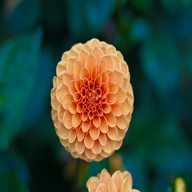

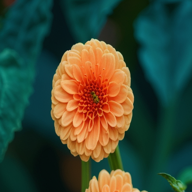

In [7]:
!pip -q install diffusers
from diffusers import AutoPipelineForImage2Image
from sklearn.datasets import load_sample_image
from PIL import Image

img = Image.fromarray(load_sample_image("flower.jpg")).resize((512, 512))   # ships with scikit-learn

i2i = AutoPipelineForImage2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
i2i = i2i.to("cuda" if torch.cuda.is_available() else "cpu")

variants = []
for _ in range(3):                                  # keep it tiny
    out = i2i("a photo of the same flower, different lighting and angle",
              image=img, num_inference_steps=4, strength=0.55, guidance_scale=0.0)
    variants.append(out.images[0])

display(img.resize((192, 192)))            # seed
display(variants[0].resize((192, 192)))    # one variant

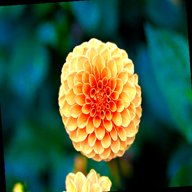

In [8]:
# Classical, zero-GPU fallback (always works): torchvision transforms.
from torchvision import transforms

classical = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.RandomRotation(15)])
display(classical(img).resize((192, 192)))

free_memory(i2i)   # release the diffusion model

## 4 · Audio — DSP augmentation (light)

For *augmentation*, audio uses cheap **DSP transforms** (add noise, time-stretch, pitch-shift).
**Label-preserving** means *modest* shifts: ±2 semitones keeps a spoken word intelligible;
±12 would not. (Generative audio — creating new clips with TTS — comes in **Lecture 2**.)

In [9]:
!pip -q install audiomentations librosa soundfile
import librosa
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
from IPython.display import Audio, display

try:
    y, sr = librosa.load(librosa.example("trumpet"))     # small sample clip
except Exception:
    sr = 22050                                           # offline fallback: a pure tone
    t = np.linspace(0, 2, 2 * sr, endpoint=False)
    y = 0.4 * np.sin(2 * np.pi * 440 * t).astype("float32")

augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.01, p=1.0),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=1.0),
    PitchShift(min_semitones=-2, max_semitones=2, p=1.0)])

y_aug = augment(samples=y, sample_rate=sr)
print("original:"); display(Audio(y, rate=sr))
print("augmented (still the same sound?):"); display(Audio(y_aug, rate=sr))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 7.7 MB/s eta 0:00:00


original:


augmented (still the same sound?):


## 5 · What to observe & discuss
* **Text:** do any paraphrases *flip* the sentiment? How does raising `temperature` change variety vs. risk?
* **Tabular:** are the SMOTE rows plausible? Did the LLM keep each note's meaning?
* **Image:** at which `strength` does the flower stop being a flower? (that is label drift)
* **Audio:** how far can you pitch-shift before the label would break?
* Why is testing on two hand-picked items **not** a fair evaluation? *(→ Lecture 7)*

### Stretch goals
* Add **class-conditional** generation for the minority class only.
* Try **LLM back-translation** (EN→DE→EN) and compare it to direct paraphrasing.
* Build a small **image** set of variants and a small **audio** set, ready for Lecture 3.

---
*Next: Lecture 2 — Synthetic Data Generation with Generative AI (creating data from scratch).*